# 03 — Fairness Audit (Phase B)
Evaluate model equity across Indigenous Status, Gender, and Age groups.

**Alert threshold:** recall gap > 0.10 between groups = ALERT

**Model:** Phase B (23 features, threshold 0.32)

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from fairlearn.metrics import MetricFrame, false_negative_rate, selection_rate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import glob

from src.feature_engineering import get_X_y
from src.config import TRAIN_TEST_DATE

In [3]:
print("hola")

hola


## 1. Load model and test data

In [4]:
# Load the most recently saved Phase B model
model_files = sorted(glob.glob('../models/phase_b_model1_*.pkl'))
artifact = joblib.load(model_files[-1])
model = artifact['model']
print(f'Loadedmar: {model_files[-1]}')

# Load processed dataset
training_df = pd.read_parquet('../data/processed/training_dataset.parquet')
X, y = get_X_y(training_df)

test_mask = training_df['Date Client Record Was Created'] >= TRAIN_TEST_DATE
X_test = X[test_mask]
y_test = y[test_mask]
training_test = training_df[test_mask].copy()

# Updated threshold (recalibrated from 0.20 in Phase B)
THRESHOLD = 0.32
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= THRESHOLD).astype(int)
print(f'Test set: {len(X_test):,} clients | Threshold: {THRESHOLD}')


Loadedmar: ../models/phase_b_model1_20260712.pkl
Test set: 2,349 clients | Threshold: 0.32


## 2. Define sensitive groups

In [5]:
# Indigenous Status
sensitive_indigenous = training_test['indigenous_status'].fillna('Unknown')

# Gender
sensitive_gender = training_test['gender'].fillna('Unknown')

# Age group
def age_group(age):
    if pd.isna(age): return 'Unknown'
    if age < 25:     return 'Youth (<25)'
    if age <= 55:    return 'Adult (25-55)'
    return 'Senior (>55)'

sensitive_age = training_test['age'].apply(age_group)

## 3. MetricFrame — Indigenous Status

In [6]:
from functools import partial

metrics = {
    'accuracy'           : accuracy_score,
    'precision'          : partial(precision_score, zero_division=0),
    'recall'             : partial(recall_score,    zero_division=0),
    'f1'                 : partial(f1_score,        zero_division=0),
    'false_negative_rate': false_negative_rate,
}

mf_indigenous = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_indigenous,
)

print('=== Indigenous Status ===')
print(mf_indigenous.by_group.round(3))
print(f'\nOverall recall: {mf_indigenous.overall["recall"]:.3f}')
print(f'Recall range:   {mf_indigenous.difference()["recall"]:.3f} (alert if > 0.10)')

=== Indigenous Status ===
                   accuracy  precision  recall     f1  false_negative_rate
indigenous_status                                                         
Indigenous            0.737      0.568   0.962  0.714                0.038
Non-Indigenous        0.764      0.412   0.783  0.540                0.217
Unknown               0.774      0.410   0.883  0.560                0.117

Overall recall: 0.812
Recall range:   0.179 (alert if > 0.10)


## 4. MetricFrame — Gender

In [7]:
mf_gender = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_gender,
)

print("=== Gender ===")
print(mf_gender.by_group.round(3))
print(f"\nRecall range: {mf_gender.difference()['recall']:.3f}")

=== Gender ===
         accuracy  precision  recall     f1  false_negative_rate
gender                                                          
Female      0.815      0.404   0.781  0.533                0.219
Male        0.723      0.427   0.824  0.563                0.176
Other       0.667      0.471   1.000  0.640                0.000
Unknown     1.000      0.000   0.000  0.000                0.000

Recall range: 1.000


## 5. MetricFrame — Age Group

In [8]:
mf_age = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_age,
)

print("=== Age Group ===")
print(mf_age.by_group.round(3))
print(f"\nRecall range: {mf_age.difference()['recall']:.3f}")

=== Age Group ===
               accuracy  precision  recall     f1  false_negative_rate
age                                                                   
Adult (25-55)     0.771      0.421   0.877  0.569                0.123
Senior (>55)      0.796      0.451   0.952  0.612                0.048
Youth (<25)       0.723      0.388   0.551  0.456                0.449

Recall range: 0.401


## 6. Summary — deploy decision

In [9]:
ALERT_THRESHOLD = 0.10

checks = {
    'Indigenous recall gap': mf_indigenous.difference()['recall'],
    'Gender recall gap'    : mf_gender.difference()['recall'],
    'Age recall gap'       : mf_age.difference()['recall'],
}

print("=== FAIRNESS AUDIT SUMMARY ===")
all_pass = True
for check, value in checks.items():
    status = 'PASS' if value <= ALERT_THRESHOLD else 'ALERT'
    if status == 'ALERT': all_pass = False
    print(f"  {status}  {check}: {value:.3f} (threshold: {ALERT_THRESHOLD})")

# Critical check: Indigenous clients must not have highest False Negative Rate
indigenous_fnr = mf_indigenous.by_group['false_negative_rate']
max_fnr_group = indigenous_fnr.idxmax()
print(f"\n  FNR by Indigenous Status:")
print(indigenous_fnr.round(3).to_string())
if max_fnr_group == 'Indigenous':
    print("\n  CRITICAL FAILURE: Indigenous clients have the highest False Negative Rate.")
    print("  DO NOT DEPLOY — review model before use.")
    all_pass = False
else:
    print(f"\n  OK — Indigenous clients do NOT have the highest FNR (highest: {max_fnr_group})")

print(f"\n{'DEPLOY APPROVED' if all_pass else 'REVIEW REQUIRED BEFORE DEPLOY'}")

=== FAIRNESS AUDIT SUMMARY ===
  ALERT  Indigenous recall gap: 0.179 (threshold: 0.1)
  ALERT  Gender recall gap: 1.000 (threshold: 0.1)
  ALERT  Age recall gap: 0.401 (threshold: 0.1)

  FNR by Indigenous Status:
indigenous_status
Indigenous        0.038
Non-Indigenous    0.217
Unknown           0.117

  OK — Indigenous clients do NOT have the highest FNR (highest: Non-Indigenous)

REVIEW REQUIRED BEFORE DEPLOY


## 7. Recall by group — visual

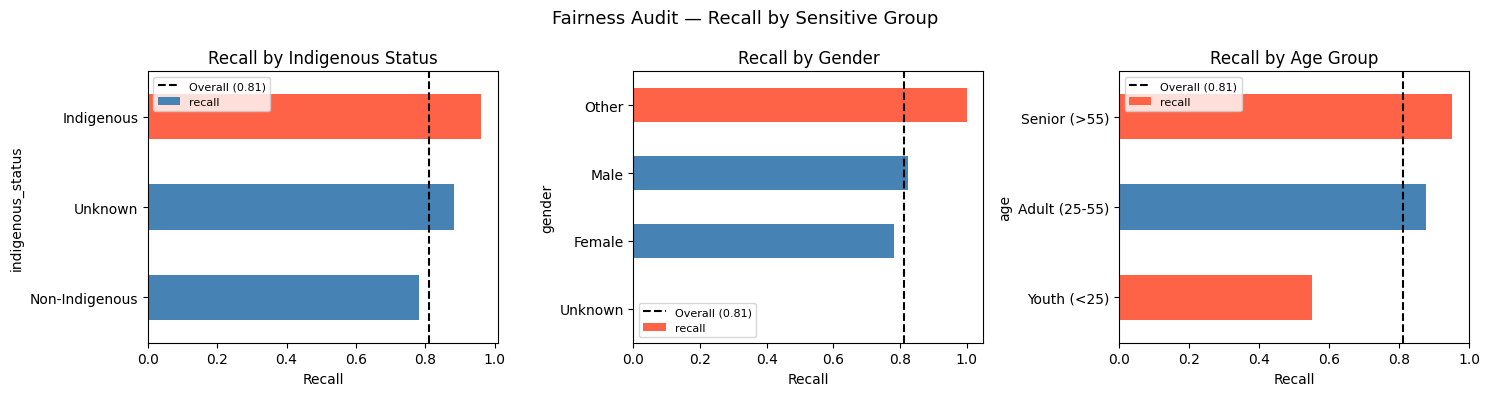

Red bars = group recall differs > 10% from overall — requires review


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
overall_recall = recall_score(y_test, y_pred)

for ax, (mf, title) in zip(axes, [
    (mf_indigenous, 'Indigenous Status'),
    (mf_gender,     'Gender'),
    (mf_age,        'Age Group'),
]):
    recalls = mf.by_group['recall'].sort_values()
    colors = ['tomato' if abs(r - overall_recall) > ALERT_THRESHOLD else 'steelblue'
              for r in recalls]
    recalls.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(overall_recall, color='black', linestyle='--', label=f'Overall ({overall_recall:.2f})')
    ax.set_title(f'Recall by {title}')
    ax.set_xlabel('Recall')
    ax.legend(fontsize=8)

plt.suptitle('Fairness Audit — Recall by Sensitive Group', fontsize=13)
plt.tight_layout()
plt.show()
print('Red bars = group recall differs > 10% from overall — requires review')